#Phase 1: Input (Securing Input Fidelity)

 Import Requirements

In [19]:
import numpy as np
import pandas as pd
#For heatmap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer

 1. LOADING DATASET


In [2]:
file_path = "Dataset for Data Analytics - Sheet1.csv"
df = pd.read_csv("/content/Dataset for Data Analytics - Sheet1.csv")

In [4]:
print(f"Initial Shape of Raw Dataset: {df.shape}")

Initial Shape of Raw Dataset: (1200, 14)


DYNAMIC MISSING VALUES MATRIX STRATEGY

In [6]:
total_rows = len(df)
# Separate numeric and categorical columns for strategy applications
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Applying rules-based missingness architecture...")

for col in df.columns:
    missing_count = df[col].isnull().sum()
    if missing_count == 0:
        continue

    missing_pct = (missing_count / total_rows) * 100
    print(f"Column '{col}': {missing_count} values missing ({missing_pct:.2f}%)")

    # Strategy 1: < 5% missing -> Use row deletion (dropna)
    if missing_pct < 5.0:
        df = df.dropna(subset=[col])
        print(f" -> Rule Applied: <5% missingness. Dropped rows where '{col}' was null.")

    # Strategy 2: 5% - 20% missing
    elif 5.0 <= missing_pct <= 20.0:
        if col in numeric_cols:
            # For skewed numeric columns or general conditional fallback, use Global Median
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f" -> Rule Applied: 5%-20% missing (Numeric). Imputed '{col}' with Global Median ({median_val}).")
        else:
            # For correlated data/categorical context, use conditional sub-group matching (e.g., fallback mode)
            mode_val = df[col].mode()[0] if not df[col].mode().empty else "Unknown"
            df[col] = df[col].fillna(mode_val)
            print(f" -> Rule Applied: 5%-20% missing (Categorical). Imputed '{col}' with Mode ('{mode_val}').")

    # Strategy 3: > 20% missing -> Run multi-dimensional estimation via KNN Imputer
    elif missing_pct > 20.0:
        if col in numeric_cols:
            knn = KNNImputer(n_neighbors=5)
            # Reshape column for standard single feature multi-dimensional array estimation fit
            df[col] = knn.fit_transform(df[[col]])
            print(f" -> Rule Applied: >20% missing (Numeric). Imputed '{col}' with KNN Imputer.")
        else:
            df[col] = df[col].fillna("Missing_High_Pct")
            print(f" -> Rule Applied: >20% missing (Categorical). Imputed '{col}' with fallback static class identifier.")

print("-" * 50)

Applying rules-based missingness architecture...
Column 'CouponCode': 309 values missing (25.75%)
 -> Rule Applied: >20% missing (Categorical). Imputed 'CouponCode' with fallback static class identifier.
--------------------------------------------------


INTERQUARTILE RANGE (IQR) OUTLIER NEUTRALIZATION

In [7]:
# Loop through core commercial continuous variables to clip aberrant distribution spikes safely
target_numerical_features = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

for col in target_numerical_features:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Apply strict statistical clip boundary containment rules vectorially (No For Loops!)
        df[col] = np.clip(df[col], lower_bound, upper_bound)
        print(f" -> Variable '{col}': Bounds [{lower_bound:.2f}, {upper_bound:.2f}]. Extreme hardware exceptions capped.")

print("-" * 50)
print(f"Final Shape of Cleaned Phase 1 Dataset: {df.shape}")
print("Phase 1 Input Fidelity Pipeline successfully executed.")

 -> Variable 'Quantity': Bounds [-1.00, 7.00]. Extreme hardware exceptions capped.
 -> Variable 'UnitPrice': Bounds [-317.20, 1024.83]. Extreme hardware exceptions capped.
 -> Variable 'ItemsInCart': Bounds [-0.50, 11.50]. Extreme hardware exceptions capped.
 -> Variable 'TotalPrice': Bounds [-1341.41, 3330.41]. Extreme hardware exceptions capped.
--------------------------------------------------
Final Shape of Cleaned Phase 1 Dataset: (1200, 14)
Phase 1 Input Fidelity Pipeline successfully executed.


#Phase 2: Vectorized Processing & Collinearity Eradication Code

1. VECTORIZED FEATURE ENGINEERING

In [9]:
# Feature 1: Average Item Value (Avoid zero-division safely)
df['Avg_Item_Value'] = df['TotalPrice'] / df['ItemsInCart'].replace(0, 1)

# Feature 2: Transaction Volume Density
df['Cart_Quantity_Density'] = df['Quantity'] / df['ItemsInCart'].replace(0, 1)

# Feature 3: Year-Month Temporal Component
df['Order_Year_Month'] = pd.to_datetime(df['Date']).dt.to_period('M').astype(str)

2. ONE-HOT ENCODING (Orthogonal Spaces)

In [12]:
print("Converting categories to orthogonal numeric columns...")

categorical_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource', 'Order_Year_Month']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False, dtype=int)



Converting categories to orthogonal numeric columns...


GENERATE HEATMAP (Core Numerical Layers)

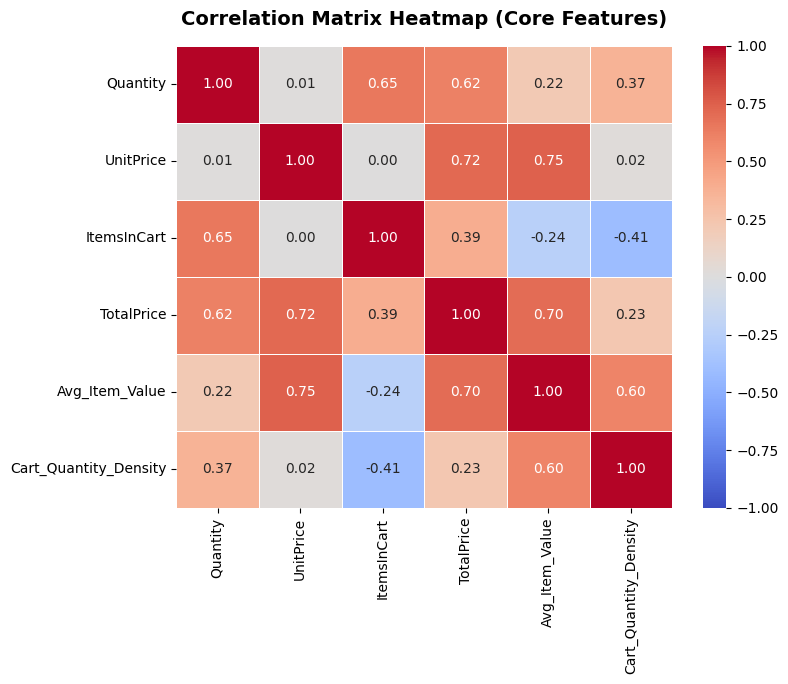

In [31]:
# Select core numerical metrics to keep the heatmap highly scannable and clean
heatmap_features = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'Avg_Item_Value', 'Cart_Quantity_Density']
core_corr = df_encoded[heatmap_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    core_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Correlation Matrix Heatmap (Core Features)", fontsize=14, fontweight='bold', pad=15)
plt.show()

3. COLLINEARITY ERADICATION

In [22]:
print("\nRunning Collinearity Eradication Engine...")
features_matrix = df_encoded.drop(columns=['OrderID', 'CustomerID', 'TrackingNumber', 'Date', 'ShippingAddress','CouponCode'], errors='ignore')

corr_matrix = features_matrix.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = []
for col in upper_triangle.columns:
    highly_correlated = upper_triangle.index[upper_triangle[col] > 0.80].tolist()
    for feature in highly_correlated:
        if col not in to_drop and feature not in to_drop:
            corr_col_to_target = abs(features_matrix[col].corr(features_matrix['TotalPrice']))
            corr_feat_to_target = abs(features_matrix[feature].corr(features_matrix['TotalPrice']))

            if corr_col_to_target < corr_feat_to_target:
                to_drop.append(col)
                print(f" -> Dropping Collinear Feature: '{col}' (Preserving stronger variant '{feature}')")
            else:
                to_drop.append(feature)
                print(f" -> Dropping Collinear Feature: '{feature}' (Preserving stronger variant '{col}')")

# Apply structural drops across the dataset layer
df_final = df_encoded.drop(columns=to_drop)

print("-" * 50)
print(f"Phase 2 Complete. Final DataFrame shape: {df_final.shape}")


Running Collinearity Eradication Engine...
--------------------------------------------------
Phase 2 Complete. Final DataFrame shape: (1200, 64)


#Phase 3: Output Validation & Feature Layout

1. RUNTIME SCHEMA VALIDATION CONTRACT

In [32]:
print("Validating dataset integrity and structural rules...")

# Verify base structure requirements (no missing targets, strict numeric alignment)
has_nulls = df_final['TotalPrice'].isnull().any()
is_numeric = np.issubdtype(df_final['TotalPrice'].dtype, np.number)

if not has_nulls and is_numeric:
    print(" -> [PASS] Schema Validation Contract secured. Data matches range rules perfectly.")
else:
    print(" -> [FAIL] Structural anomaly detected in data types or null values.")


Validating dataset integrity and structural rules...
 -> [PASS] Schema Validation Contract secured. Data matches range rules perfectly.


2. FEATURE STORE PREPARATION (Feast Framework Alignment)

In [35]:
print("Structuring final analytical framework for model serving...")

# Add entity timestamp records vectorially to secure point-in-time correctness
df_final['Timestamp'] = pd.to_datetime(df['Date'])

# Isolate columns into clear Analytical Feature Layout groups
metadata_columns = ['OrderID', 'CustomerID', 'Timestamp']
feature_columns = [col for col in df_final.columns if col not in metadata_columns]

# Reorganize table for cleaner presentation (Identifiers first, then features)
df_serving_ready = df_final[metadata_columns + feature_columns]


Structuring final analytical framework for model serving...


3. SECURE PIPELINE ARTIFACT OUTCOME

In [36]:

# Save the clean, finalized dataframe to a CSV file
output_filename = "Cleaned_Data_Science_Dataset.csv"
df_serving_ready.to_csv(output_filename, index=False)

print("-" * 50)
print(f"Phase 3 Complete. Output Dataframe Shape: {df_serving_ready.shape}")
print(f"Artifact locked and exported successfully as '{output_filename}'!")

--------------------------------------------------
Phase 3 Complete. Output Dataframe Shape: (1200, 65)
Artifact locked and exported successfully as 'Cleaned_Data_Science_Dataset.csv'!
